# Ablation Study: AICoreDetector
## Анализ вклада отдельных признаков и групп признаков

Данный блокнот исследует, насколько каждый признак (и каждая гипотетическая группа признаков)  
вносит вклад в качество классификации. Эксперименты:

| # | Эксперимент | Описание |
|---|-------------|----------|
| 1 | **Leave-One-Out** | Удаляем по одному признаку, смотрим на ΔF1 и ΔAUC |
| 2 | **Leave-Group-Out** | Удаляем целые гипотетические группы (Г1–Г4 + control) |
| 3 | **Incremental Add** | Добавляем признаки по убыванию важности (MDI) |
| 4 | **Минимальный подмножество** | Сколько признаков нужно для 95% от полной метрики? |
| 5 | **total_tokens check** | Отдельная проверка: влияние контрольного параметра |

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score

sys.path.insert(0, os.path.abspath('.'))
from src.features import get_syntactic_features, FEATURE_NAMES, N_FEATURES
from src.model import AICoreDetector

# ── Стиль ──
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11, 'axes.titlesize': 12})
sns.set_theme(style='whitegrid')

RESULTS_DIR = "results"
print(f'Признаков: {N_FEATURES}')
print('FEATURE_NAMES:', FEATURE_NAMES)


Признаков: 15
FEATURE_NAMES: ['avg_sent_len', 'burstiness', 'punct_entropy', 'punct_density', 'avg_dep_depth', 'nv_ratio', 'ttr', 'hlr', 'complexity_ratio', 'passive_ratio', 'comma_cv', 'cr_pos', 'unique_trigrams_per_tok', 'pos_entropy', 'total_tokens']


## 1. Загрузка данных и кэша признаков


In [ ]:
# ── Загрузка кэша признаков (создан в solution.ipynb) ──
FEAT_CACHE  = 'cache/features_cache.npy'
LABEL_CACHE = 'cache/labels_cache.npy'

if os.path.exists(FEAT_CACHE) and os.path.exists(LABEL_CACHE):
    X_all = np.load(FEAT_CACHE)
    y_all = np.load(LABEL_CACHE)
    print(f'Загружено из кэша: X={X_all.shape}, y={y_all.shape}')
else:
    raise FileNotFoundError(
        'Кэш признаков не найден. Запустите solution.ipynb для создания '
        'cache/features_cache.npy и cache/labels_cache.npy'
    )

# Тот же split что и в solution.ipynb 
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Баланс (test): Human={sum(y_test==0):,}, AI={sum(y_test==1):,}')


Загружено из кэша: X=(9995, 15), y=(9995,)
Train: 7,996  |  Test: 1,999
Баланс (test): Human=1,000, AI=999


## 2. Базовые метрики: полный набор из 15 признаков


In [3]:
def eval_rf(X_tr, X_te, y_tr, y_te):
    """Обучает RF на X_tr/y_tr, возвращает метрики на X_te/y_te."""
    clf = RandomForestClassifier(
        n_estimators=200, criterion='gini',
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]
    return {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred, zero_division=0),
        'F1':        f1_score(y_te, y_pred, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_te, y_prob),
    }, clf

# Полный набор (baseline)
BASELINE_METRICS, clf_full = eval_rf(X_train, X_test, y_train, y_test)

print('Базовые метрики (все 15 признаков):')
for k, v in BASELINE_METRICS.items():
    print(f'  {k:10s}: {v:.4f}')


Базовые метрики (все 15 признаков):
  Accuracy  : 0.9020
  Precision : 0.9161
  Recall    : 0.8849
  F1        : 0.9002
  AUC-ROC   : 0.9624


## 3. Эксперимент 1: Leave-One-Out

Удаляем по одному признаку и измеряем деградацию.  
ΔF1 = F1(без признака) − F1(полная модель).  
Отрицательные значения означают, что признак полезен.


In [4]:
loo_rows = []

for drop_idx, feat_name in enumerate(tqdm(FEATURE_NAMES, desc='LOO')):
    keep = [i for i in range(N_FEATURES) if i != drop_idx]
    m, _ = eval_rf(
        X_train[:, keep], X_test[:, keep], y_train, y_test
    )
    loo_rows.append({
        'Признак':    feat_name,
        'F1':         m['F1'],
        'AUC-ROC':    m['AUC-ROC'],
        'Accuracy':   m['Accuracy'],
        'ΔF1':        m['F1']  - BASELINE_METRICS['F1'],
        'ΔAUC':       m['AUC-ROC'] - BASELINE_METRICS['AUC-ROC'],
    })

loo_df = pd.DataFrame(loo_rows).sort_values('ΔF1')
print('Leave-One-Out результаты (сортировка по ΔF1, наиболее важные — первые):')
display(loo_df.round(4))


LOO: 100%|██████████| 15/15 [05:51<00:00, 23.42s/it]


Leave-One-Out результаты (сортировка по ΔF1, наиболее важные — первые):


,Признак,F1,AUC-ROC,Accuracy,ΔF1,ΔAUC
2,punct_entropy,0.8793,0.9502,0.8824,-0.0209,-0.0122
1,burstiness,0.8829,0.9534,0.8854,-0.0173,-0.0090
4,avg_dep_depth,0.8944,0.9570,0.8964,-0.0058,-0.0054
10,comma_cv,0.8968,0.9621,0.8989,-0.0034,-0.0003
13,pos_entropy,0.8969,0.9598,0.8989,-0.0033,-0.0026
5,nv_ratio,0.8976,0.9615,0.8994,-0.0026,-0.0009
14,total_tokens,0.8986,0.9596,0.9005,-0.0016,-0.0028
8,complexity_ratio,0.8993,0.9624,0.9015,-0.0009,-0.0000
0,avg_sent_len,0.8997,0.9613,0.9015,-0.0005,-0.0011
3,punct_density,0.9000,0.9624,0.9020,-0.0002,0.0000


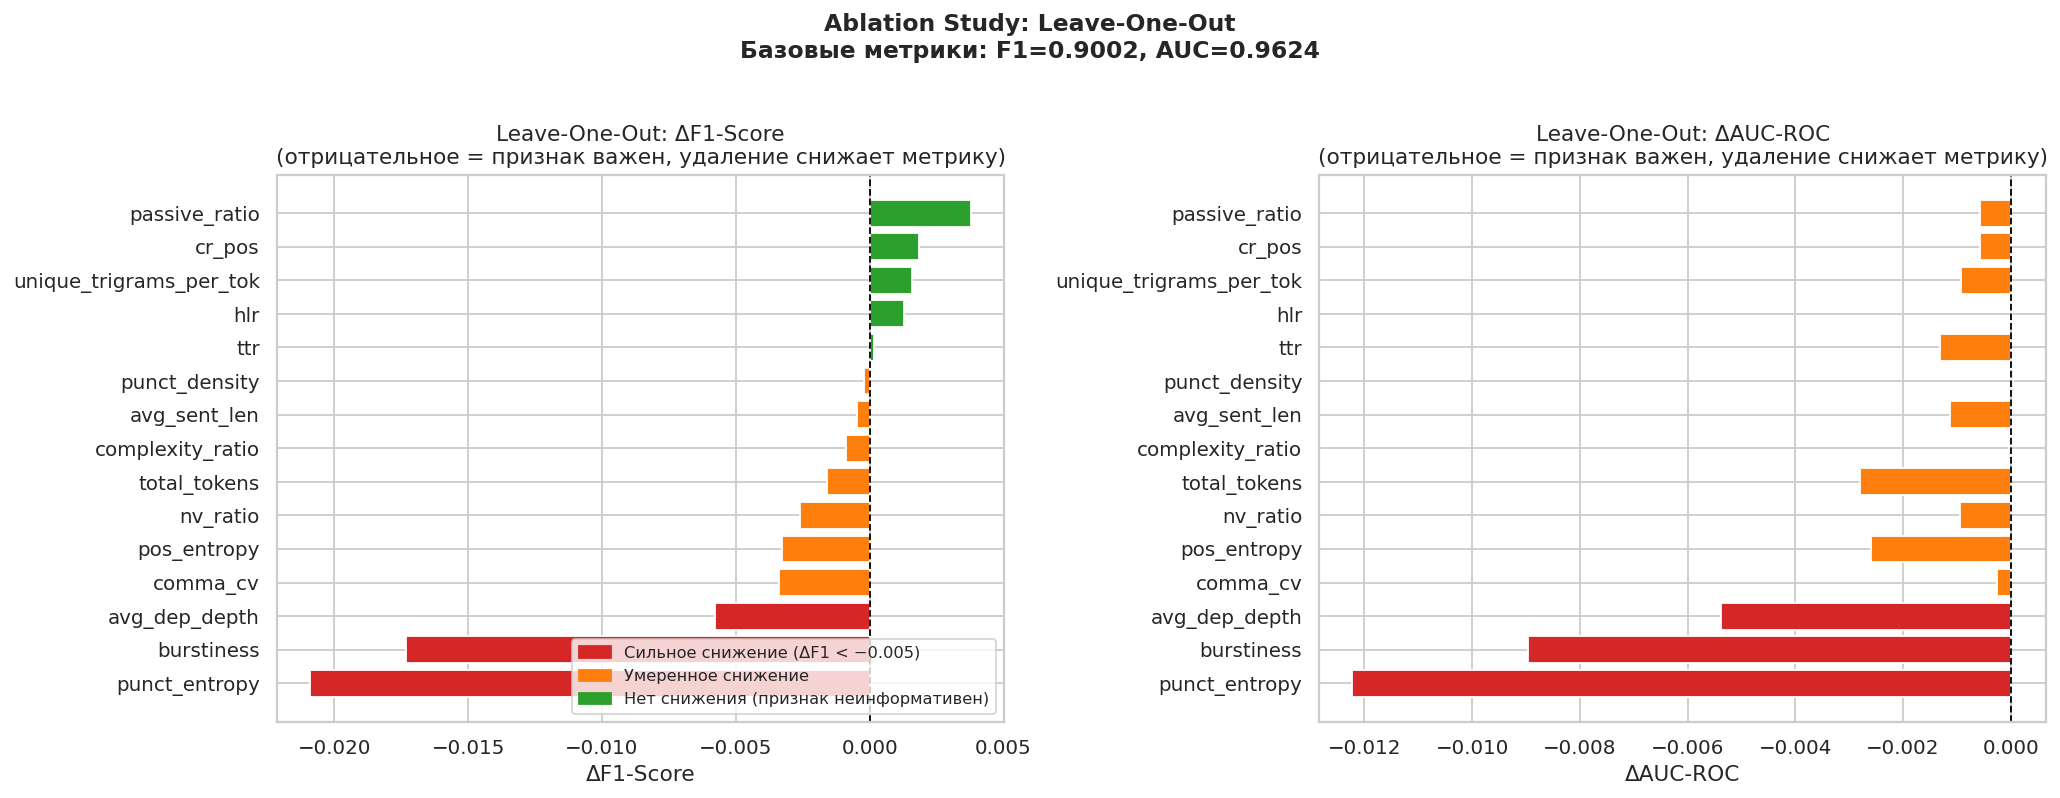

Сохранено: figures/ablation_loo.png


In [ ]:
# ── Визуализация LOO ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, label in zip(axes, ['ΔF1', 'ΔAUC'], ['ΔF1-Score', 'ΔAUC-ROC']):
    colors = ['#d62728' if v < -0.005 else '#ff7f0e' if v < 0 else '#2ca02c'
              for v in loo_df[col]]
    ax.barh(loo_df['Признак'], loo_df[col], color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=1.0, ls='--')
    ax.set_xlabel(label)
    ax.set_title(f'Leave-One-Out: {label}\n'
                 f'(отрицательное = признак важен, удаление снижает метрику)')

# Легенда
patches = [
    mpatches.Patch(color='#d62728', label='Сильное снижение (ΔF1 < −0.005)'),
    mpatches.Patch(color='#ff7f0e', label='Умеренное снижение'),
    mpatches.Patch(color='#2ca02c', label='Нет снижения (признак неинформативен)'),
]
axes[0].legend(handles=patches, fontsize=9, loc='lower right')

plt.suptitle('Ablation Study: Leave-One-Out\nБазовые метрики: '
             f'F1={BASELINE_METRICS["F1"]:.4f}, AUC={BASELINE_METRICS["AUC-ROC"]:.4f}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/ablation_loo.png', bbox_inches='tight')
plt.show()
print('Сохранено: results/ablation_loo.png')


## 4. Эксперимент 2: Leave-Group-Out

Удаляем целые группы признаков, соответствующие гипотезам Г1–Г4 и контрольному параметру.

| Группа | Гипотеза | Признаки |
|--------|----------|----------|
| Г1 | Синтаксическая шаблонность | cr_pos, unique_trigrams_per_tok, pos_entropy, avg_dep_depth |
| Г2 | Пунктуационная вариативность | punct_entropy, punct_density, comma_cv, burstiness |
| Г3 | Стилистическая «гладкость» | ttr, hlr, avg_sent_len, nv_ratio |
| Г4 | Структурное несоответствие | complexity_ratio, passive_ratio |
| control | Контрольный параметр | total_tokens |


In [6]:
# Группы признаков по гипотезам
GROUPS = {
    'Г1 (Синтаксис)':     ['cr_pos', 'unique_trigrams_per_tok', 'pos_entropy', 'avg_dep_depth'],
    'Г2 (Пунктуация)':    ['punct_entropy', 'punct_density', 'comma_cv', 'burstiness'],
    'Г3 (Лексика/стиль)': ['ttr', 'hlr', 'avg_sent_len', 'nv_ratio'],
    'Г4 (Структура)':     ['complexity_ratio', 'passive_ratio'],
    'Control':            ['total_tokens'],
}

# Проверяем, что все признаки из групп есть в FEATURE_NAMES
for grp, feats in GROUPS.items():
    missing = [f for f in feats if f not in FEATURE_NAMES]
    if missing:
        print(f'WARNING: признаки {missing} не найдены в FEATURE_NAMES!')

group_rows = []
for grp_name, drop_feats in GROUPS.items():
    keep_idx = [i for i, f in enumerate(FEATURE_NAMES) if f not in drop_feats]
    m, _ = eval_rf(
        X_train[:, keep_idx], X_test[:, keep_idx], y_train, y_test
    )
    group_rows.append({
        'Группа':          grp_name,
        'Удалено признаков': len(drop_feats),
        'Осталось':         N_FEATURES - len(drop_feats),
        'F1':              m['F1'],
        'AUC-ROC':         m['AUC-ROC'],
        'Accuracy':        m['Accuracy'],
        'ΔF1':             m['F1']  - BASELINE_METRICS['F1'],
        'ΔAUC':            m['AUC-ROC'] - BASELINE_METRICS['AUC-ROC'],
    })

group_df = pd.DataFrame(group_rows).sort_values('ΔF1')
print('Leave-Group-Out результаты:')
display(group_df.round(4))


Leave-Group-Out результаты:


,Группа,Удалено признаков,Осталось,F1,AUC-ROC,Accuracy,ΔF1,ΔAUC
1,Г2 (Пунктуация),4,11,0.8409,0.9233,0.8429,-0.0593,-0.0390
2,Г3 (Лексика/стиль),4,11,0.8761,0.9484,0.8804,-0.0241,-0.0139
0,Г1 (Синтаксис),4,11,0.8895,0.9535,0.8914,-0.0107,-0.0089
4,Control,1,14,0.8986,0.9596,0.9005,-0.0016,-0.0028
3,Г4 (Структура),2,13,0.9034,0.9625,0.9055,0.0032,0.0001


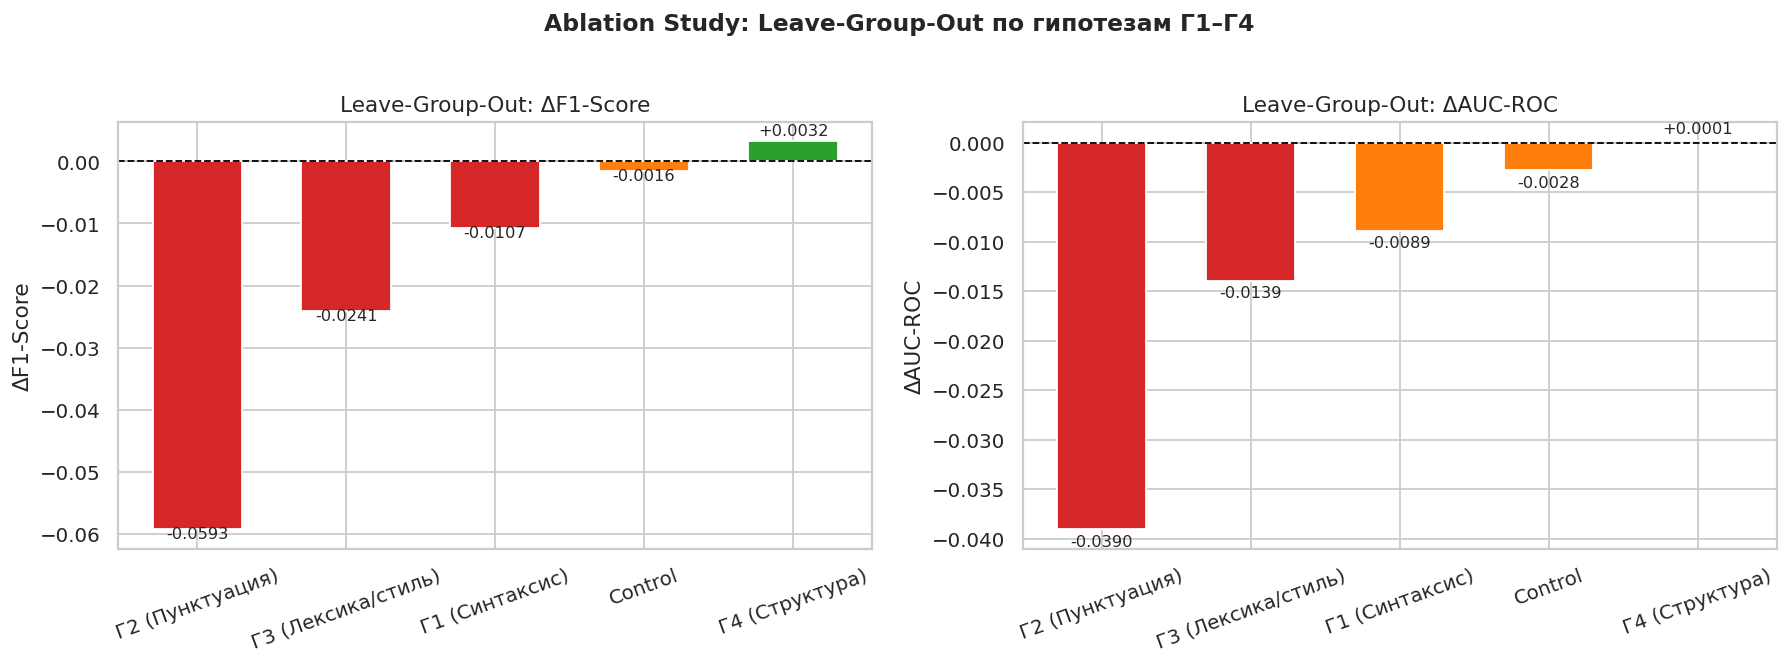

Сохранено: figures/ablation_groups.png


In [ ]:
# ── Визуализация групп ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(axes, ['ΔF1', 'ΔAUC'], ['ΔF1-Score', 'ΔAUC-ROC']):
    colors = ['#d62728' if v < -0.01 else '#ff7f0e' if v < 0 else '#2ca02c'
              for v in group_df[col]]
    bars = ax.bar(group_df['Группа'], group_df[col], color=colors, edgecolor='white', width=0.6)
    ax.axhline(0, color='black', lw=1.0, ls='--')
    ax.set_ylabel(label)
    ax.set_title(f'Leave-Group-Out: {label}')
    ax.tick_params(axis='x', rotation=20)
    for bar, v in zip(bars, group_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.0005 if v >= 0 else -0.002),
                f'{v:+.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Ablation Study: Leave-Group-Out по гипотезам Г1–Г4',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/ablation_groups.png', bbox_inches='tight')
plt.show()
print('Сохранено: results/ablation_groups.png')


## 5. Эксперимент 3: Инкрементальное добавление признаков

Добавляем признаки по убыванию MDI-важности (от самого важного к наименее важному).  
Показывает, при каком минимальном числе признаков модель выходит на плато.


In [8]:
# Порядок признаков по MDI-важности (из полной модели)
mdi_importance = clf_full.feature_importances_
mdi_order = np.argsort(mdi_importance)[::-1]  # по убыванию

print('Порядок признаков по MDI-важности:')
for rank, idx in enumerate(mdi_order):
    print(f'  {rank+1:2d}. {FEATURE_NAMES[idx]:30s} MDI={mdi_importance[idx]:.4f}')


Порядок признаков по MDI-важности:
   1. punct_entropy                  MDI=0.1987
   2. burstiness                     MDI=0.1541
   3. ttr                            MDI=0.1011
   4. punct_density                  MDI=0.0832
   5. avg_dep_depth                  MDI=0.0761
   6. hlr                            MDI=0.0708
   7. total_tokens                   MDI=0.0538
   8. unique_trigrams_per_tok        MDI=0.0449
   9. cr_pos                         MDI=0.0429
  10. comma_cv                       MDI=0.0418
  11. avg_sent_len                   MDI=0.0414
  12. pos_entropy                    MDI=0.0252
  13. complexity_ratio               MDI=0.0233
  14. nv_ratio                       MDI=0.0233
  15. passive_ratio                  MDI=0.0194


In [9]:
incremental_rows = []

for n_feats in tqdm(range(1, N_FEATURES + 1), desc='Incremental'):
    subset_idx = mdi_order[:n_feats]
    m, _ = eval_rf(
        X_train[:, subset_idx], X_test[:, subset_idx], y_train, y_test
    )
    incremental_rows.append({
        'N признаков': n_feats,
        'Признаки':    ', '.join(FEATURE_NAMES[i] for i in subset_idx),
        'F1':          m['F1'],
        'AUC-ROC':     m['AUC-ROC'],
        'Accuracy':    m['Accuracy'],
    })

incr_df = pd.DataFrame(incremental_rows)
print('Инкрементальное добавление признаков:')
display(incr_df[['N признаков', 'F1', 'AUC-ROC', 'Accuracy']].round(4))


Incremental: 100%|██████████| 15/15 [05:09<00:00, 20.64s/it]

Инкрементальное добавление признаков:


,N признаков,F1,AUC-ROC,Accuracy
0,1,0.6922,0.7825,0.6908
1,2,0.7826,0.8549,0.7874
2,3,0.8558,0.9197,0.8604
3,4,0.8655,0.9296,0.8684
4,5,0.8789,0.9452,0.8819
5,6,0.8776,0.9464,0.8809
6,7,0.8935,0.9556,0.8949
7,8,0.8964,0.9594,0.8984
8,9,0.8979,0.9605,0.8999
9,10,0.8972,0.9610,0.8994


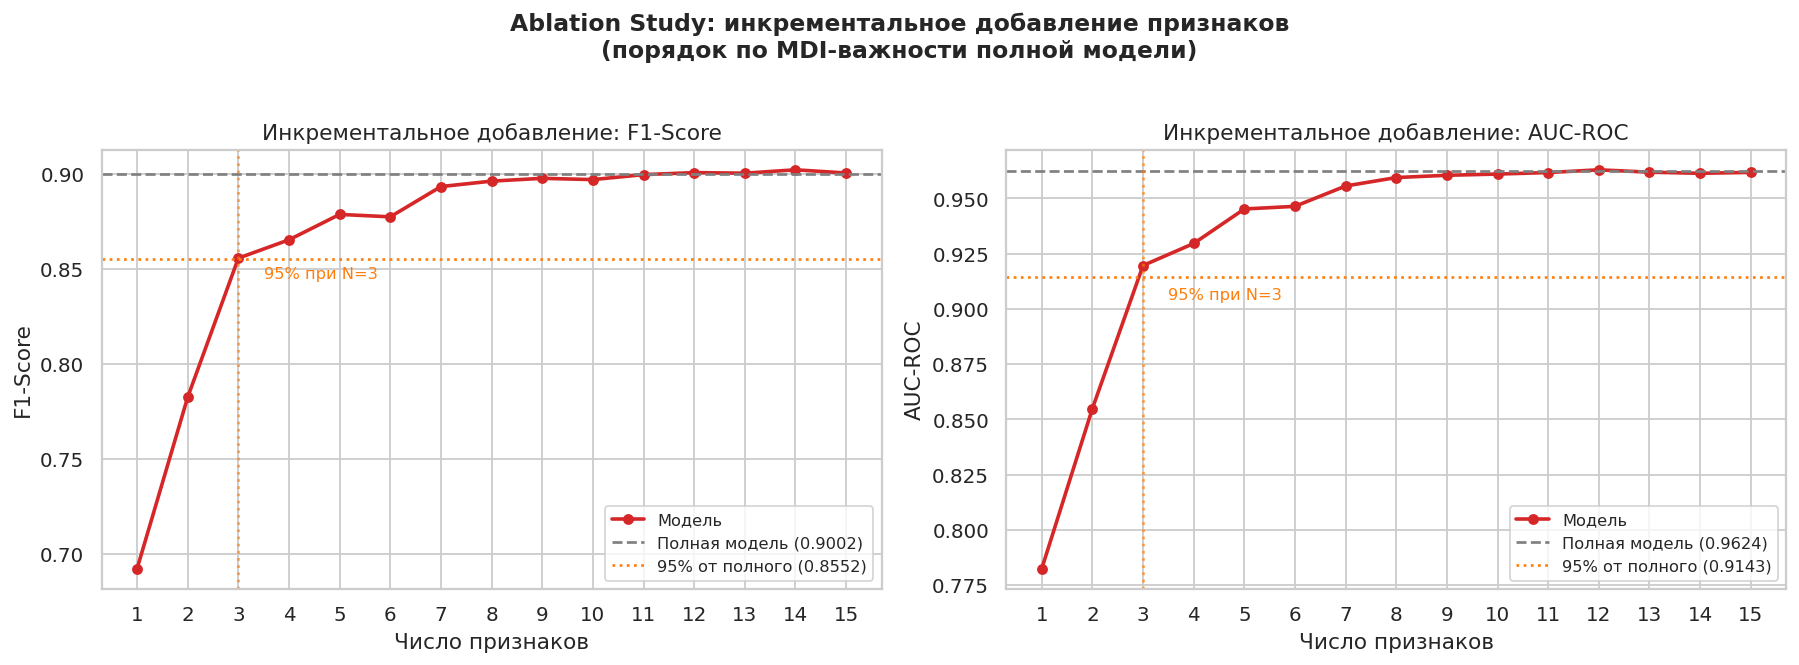

Сохранено: figures/ablation_incremental.png


In [ ]:
# ── Визуализация Incremental ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Порог 95% от полного качества
threshold_f1  = BASELINE_METRICS['F1']   * 0.95
threshold_auc = BASELINE_METRICS['AUC-ROC'] * 0.95

for ax, col, label, threshold in zip(
    axes,
    ['F1', 'AUC-ROC'],
    ['F1-Score', 'AUC-ROC'],
    [threshold_f1, threshold_auc]
):
    ax.plot(incr_df['N признаков'], incr_df[col],
            marker='o', markersize=5, lw=2, color='#d62728', label='Модель')
    ax.axhline(BASELINE_METRICS[col], color='gray', ls='--', lw=1.5,
               label=f'Полная модель ({BASELINE_METRICS[col]:.4f})')
    ax.axhline(threshold, color='#ff7f0e', ls=':', lw=1.5,
               label=f'95% от полного ({threshold:.4f})')

    # Находим минимальное N для достижения 95%
    idx_95 = incr_df[incr_df[col] >= threshold]['N признаков'].min()
    if not np.isnan(idx_95):
        ax.axvline(idx_95, color='#ff7f0e', ls=':', alpha=0.7)
        ax.annotate(f'95% при N={int(idx_95)}',
                    xy=(idx_95, threshold),
                    xytext=(idx_95 + 0.5, threshold - 0.01),
                    fontsize=9, color='#ff7f0e')

    ax.set_xlabel('Число признаков')
    ax.set_ylabel(label)
    ax.set_xticks(range(1, N_FEATURES + 1))
    ax.set_title(f'Инкрементальное добавление: {label}')
    ax.legend(fontsize=9)

plt.suptitle('Ablation Study: инкрементальное добавление признаков\n'
             '(порядок по MDI-важности полной модели)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/ablation_incremental.png', bbox_inches='tight')
plt.show()
print('Сохранено: results/ablation_incremental.png')


## 6. Эксперимент 4: Минимальное подмножество

Находим наименьшее число признаков, дающее ≥ 95% от полного F1 и AUC-ROC.
Перебираем все комбинации (для малого N) или используем жадный алгоритм.


In [11]:
# Жадный forward selection: добавляем тот признак, который даёт наибольший прирост F1
selected = []
remaining = list(range(N_FEATURES))
greedy_rows = []

for step in tqdm(range(N_FEATURES), desc='Greedy forward'):
    best_f1 = -1
    best_idx = None
    for candidate in remaining:
        trial = selected + [candidate]
        m, _ = eval_rf(
            X_train[:, trial], X_test[:, trial], y_train, y_test
        )
        if m['F1'] > best_f1:
            best_f1 = m['F1']
            best_m   = m
            best_idx = candidate

    selected.append(best_idx)
    remaining.remove(best_idx)

    greedy_rows.append({
        'Шаг':         step + 1,
        'Добавлен':    FEATURE_NAMES[best_idx],
        'Набор':       ', '.join(FEATURE_NAMES[i] for i in selected),
        'F1':          best_m['F1'],
        'AUC-ROC':     best_m['AUC-ROC'],
        'Accuracy':    best_m['Accuracy'],
        '% от F1_full': best_m['F1'] / BASELINE_METRICS['F1'] * 100,
    })

greedy_df = pd.DataFrame(greedy_rows)
print('Жадный forward selection (по F1):')
display(greedy_df[['Шаг', 'Добавлен', 'F1', 'AUC-ROC', '% от F1_full']].round(4))

# Минимальный набор для 95%
min95 = greedy_df[greedy_df['% от F1_full'] >= 95].head(1)
if len(min95):
    print(f"\n✓ 95% от F1 достигается при {min95['Шаг'].values[0]} признаках.")
    print(f"  Признаки: {min95['Набор'].values[0]}")
    print(f"  F1={min95['F1'].values[0]:.4f}, AUC={min95['AUC-ROC'].values[0]:.4f}")


Greedy forward: 100%|██████████| 15/15 [31:48<00:00, 127.22s/it]

Жадный forward selection (по F1):


,Шаг,Добавлен,F1,AUC-ROC,% от F1_full
0,1,punct_entropy,0.6922,0.7825,76.8972
1,2,ttr,0.7878,0.8746,87.5188
2,3,burstiness,0.8540,0.9206,94.8716
3,4,total_tokens,0.8797,0.9415,97.7193
4,5,avg_dep_depth,0.8910,0.9535,98.9819
5,6,avg_sent_len,0.8947,0.9568,99.3867
6,7,unique_trigrams_per_tok,0.9007,0.9595,100.0570
7,8,punct_density,0.9028,0.9603,100.2883
8,9,cr_pos,0.9053,0.9616,100.5656
9,10,nv_ratio,0.9027,0.9607,100.2773



✓ 95% от F1 достигается при 4 признаках.
  Признаки: punct_entropy, ttr, burstiness, total_tokens
  F1=0.8797, AUC=0.9415


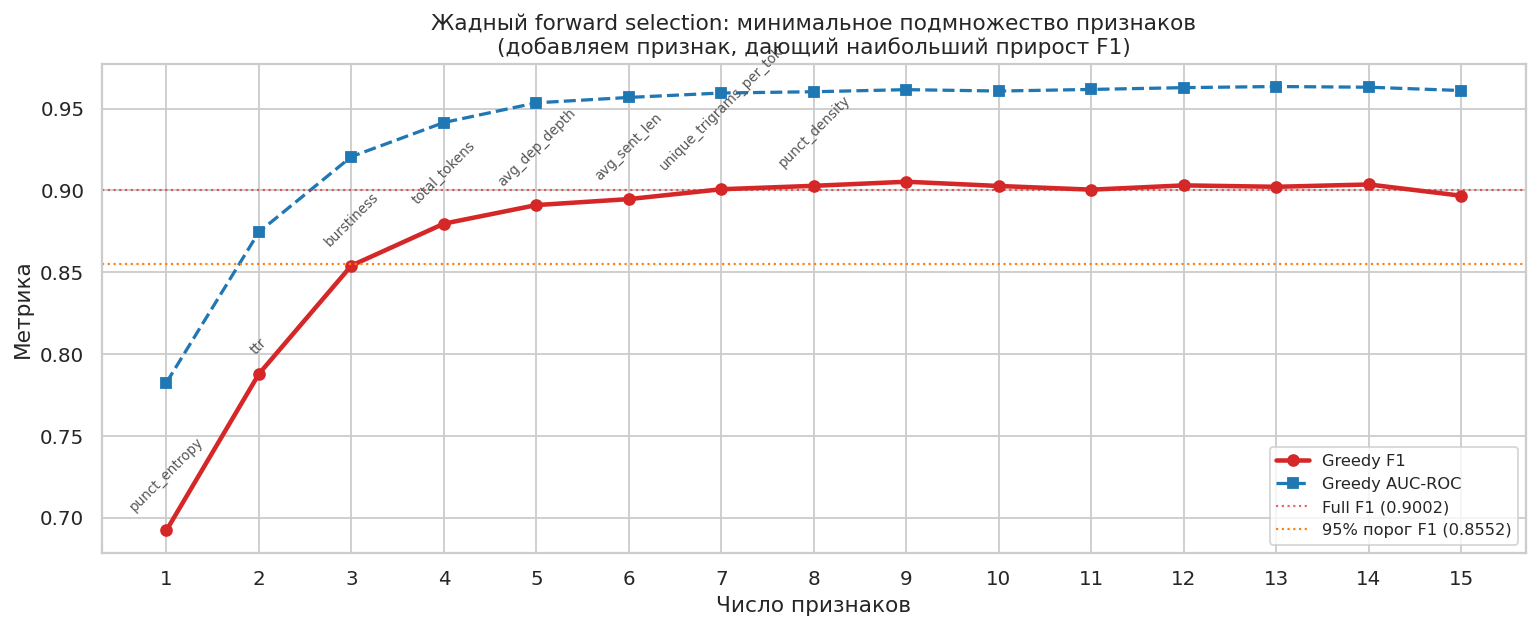

Сохранено: figures/ablation_greedy.png


In [ ]:
# ── Визуализация жадного поиска ──
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(greedy_df['Шаг'], greedy_df['F1'],
        marker='o', markersize=6, lw=2.5, color='#d62728', label='Greedy F1')
ax.plot(greedy_df['Шаг'], greedy_df['AUC-ROC'],
        marker='s', markersize=5, lw=1.8, color='#1f77b4', ls='--', label='Greedy AUC-ROC')

ax.axhline(BASELINE_METRICS['F1'], color='#d62728', ls=':', lw=1.2, alpha=0.7,
           label=f'Full F1 ({BASELINE_METRICS["F1"]:.4f})')
ax.axhline(BASELINE_METRICS['F1'] * 0.95, color='#ff7f0e', ls=':', lw=1.2,
           label=f'95% порог F1 ({BASELINE_METRICS["F1"]*0.95:.4f})')

# Аннотации добавляемых признаков
for _, row in greedy_df.iterrows():
    if row['Шаг'] <= 8:  # показываем первые 8
        ax.annotate(row['Добавлен'],
                    xy=(row['Шаг'], row['F1']),
                    xytext=(row['Шаг'], row['F1'] + 0.012),
                    ha='center', fontsize=7.5, rotation=45, color='#555')

ax.set_xlabel('Число признаков')
ax.set_ylabel('Метрика')
ax.set_xticks(greedy_df['Шаг'])
ax.set_title('Жадный forward selection: минимальное подмножество признаков\n'
             '(добавляем признак, дающий наибольший прирост F1)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/ablation_greedy.png', bbox_inches='tight')
plt.show()
print('Сохранено: results/ablation_greedy.png')


## 7. Эксперимент 5: Проверка контрольного параметра total_tokens

Отдельно проверяем: модель с total_tokens vs без него.  

In [13]:
tok_idx = FEATURE_NAMES.index('total_tokens')
without_tok = [i for i in range(N_FEATURES) if i != tok_idx]

m_with,    _ = eval_rf(X_train,                  X_test,                  y_train, y_test)
m_without, _ = eval_rf(X_train[:, without_tok], X_test[:, without_tok], y_train, y_test)
m_only,    _ = eval_rf(X_train[:, [tok_idx]],   X_test[:, [tok_idx]],   y_train, y_test)

tok_df = pd.DataFrame([
    {'Конфигурация': 'Все 15 признаков',         **m_with},
    {'Конфигурация': 'Без total_tokens (14)',     **m_without},
    {'Конфигурация': 'Только total_tokens (1)',   **m_only},
]).set_index('Конфигурация')

tok_df['ΔF1 vs full']  = tok_df['F1']     - m_with['F1']
tok_df['ΔAUC vs full'] = tok_df['AUC-ROC'] - m_with['AUC-ROC']

print('Влияние total_tokens:')
display(tok_df.round(4))

print(f"\nΔF1 при удалении total_tokens: {tok_df.loc['Без total_tokens (14)', 'ΔF1 vs full']:+.4f}")
print(f"ΔAUC при удалении total_tokens: {tok_df.loc['Без total_tokens (14)', 'ΔAUC vs full']:+.4f}")
print()
print('Вывод: если Δ < 0.005, total_tokens не вносит значимого вклада —')
print('модель классифицирует по синтаксическим структурам, а не по длине текста.')


Влияние total_tokens:


,Accuracy,Precision,Recall,F1,AUC-ROC,ΔF1 vs full,ΔAUC vs full
Конфигурация,,,,,,,
Все 15 признаков,0.9020,0.9161,0.8849,0.9002,0.9624,0.0000,0.0000
Без total_tokens (14),0.9005,0.9149,0.8829,0.8986,0.9596,-0.0016,-0.0028
Только total_tokens (1),0.5488,0.5454,0.5836,0.5638,0.5739,-0.3364,-0.3885



ΔF1 при удалении total_tokens: -0.0016
ΔAUC при удалении total_tokens: -0.0028

Вывод: если Δ < 0.005, total_tokens не вносит значимого вклада —
модель классифицирует по синтаксическим структурам, а не по длине текста.


## 8. Итоговая сводка ablation study


In [ ]:
print('='*72)
print('ИТОГОВЫЕ РЕЗУЛЬТАТЫ ABLATION STUDY')
print('='*72)

print(f'\nБазовая модель (все {N_FEATURES} признаков):')
print(f'  F1={BASELINE_METRICS["F1"]:.4f}  AUC={BASELINE_METRICS["AUC-ROC"]:.4f}  '
      f'Acc={BASELINE_METRICS["Accuracy"]:.4f}')

print('\nЭксп. 1 — Leave-One-Out:')
print('  Наиболее критичные признаки (наибольшее снижение F1 при удалении):')
for _, row in loo_df.head(5).iterrows():
    print(f'    {row["Признак"]:30s} ΔF1={row["ΔF1"]:+.4f}  ΔAUC={row["ΔAUC"]:+.4f}')

print('\n  Наименее важные признаки (удаление почти не влияет):')
for _, row in loo_df.tail(3).iterrows():
    print(f'    {row["Признак"]:30s} ΔF1={row["ΔF1"]:+.4f}  ΔAUC={row["ΔAUC"]:+.4f}')

print('\nЭксп. 2 — Leave-Group-Out:')
print('  Наиболее критичная группа:')
top_grp = group_df.iloc[0]
print(f'    {top_grp["Группа"]}  ΔF1={top_grp["ΔF1"]:+.4f}  ΔAUC={top_grp["ΔAUC"]:+.4f}')

min95_row = greedy_df[greedy_df['% от F1_full'] >= 95].head(1)
if len(min95_row):
    print(f'\nЭксп. 4 — Минимальный набор для ≥95% от F1:')
    print(f'  {min95_row["Шаг"].values[0]} признаков: {min95_row["Набор"].values[0]}')
    print(f'  F1={min95_row["F1"].values[0]:.4f}  AUC={min95_row["AUC-ROC"].values[0]:.4f}')

print(f'\nЭксп. 5 — total_tokens:')
delta_f1_tok = tok_df.loc['Без total_tokens (14)', 'ΔF1 vs full']
print(f'  ΔF1 при удалении: {delta_f1_tok:+.4f}')
if abs(delta_f1_tok) < 0.005:
    print('  → total_tokens не оказывает значимого влияния.')
    print('  → Классификация определяется синтаксическими признаками, а не объёмом текста.')
else:
    print('  → total_tokens вносит ненулевой вклад — рассмотреть исключение из набора.')

print('\nГрафики сохранены в:', RESULTS_DIR)
print('  ablation_loo.png')
print('  ablation_groups.png')
print('  ablation_incremental.png')
print('  ablation_greedy.png')


ИТОГОВЫЕ РЕЗУЛЬТАТЫ ABLATION STUDY

Базовая модель (все 15 признаков):
  F1=0.9002  AUC=0.9624  Acc=0.9020

Эксп. 1 — Leave-One-Out:
  Наиболее критичные признаки (наибольшее снижение F1 при удалении):
    punct_entropy                  ΔF1=-0.0209  ΔAUC=-0.0122
    burstiness                     ΔF1=-0.0173  ΔAUC=-0.0090
    avg_dep_depth                  ΔF1=-0.0058  ΔAUC=-0.0054
    comma_cv                       ΔF1=-0.0034  ΔAUC=-0.0003
    pos_entropy                    ΔF1=-0.0033  ΔAUC=-0.0026

  Наименее важные признаки (удаление почти не влияет):
    unique_trigrams_per_tok        ΔF1=+0.0016  ΔAUC=-0.0009
    cr_pos                         ΔF1=+0.0018  ΔAUC=-0.0006
    passive_ratio                  ΔF1=+0.0038  ΔAUC=-0.0006

Эксп. 2 — Leave-Group-Out:
  Наиболее критичная группа:
    Г2 (Пунктуация)  ΔF1=-0.0593  ΔAUC=-0.0390

Эксп. 4 — Минимальный набор для ≥95% от F1:
  4 признаков: punct_entropy, ttr, burstiness, total_tokens
  F1=0.8797  AUC=0.9415

Эксп. 5 — total_toke